In [1]:
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Check GPU availability
print("TensorFlow version:", tf.__version__)
print("CUDA built:", tf.test.is_built_with_cuda())

physical_gpus = tf.config.list_physical_devices('GPU')
print("Physical GPUs:", physical_gpus)

if physical_gpus:
    # Enable memory growth to avoid allocating all VRAM up front
    for gpu in physical_gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth enabled.")

    # Mixed precision for speed (Tensor Cores)
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled:", mixed_precision.global_policy())
else:
    print("No GPU detected. Running on CPU.")

# Optional: limit visible devices to the first GPU
# tf.config.set_visible_devices(physical_gpus[0], 'GPU')

2026-05-06 12:52:18.604227: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 12:52:18.660537: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-06 12:52:20.074166: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
CUDA built: True
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled.
Mixed precision enabled: <DTypePolicy "mixed_float16">


## 2. Load or Define xAI Models and Utilities
Load model weights or define model architectures and register xAI utilities to be used in the notebook.

In [2]:
import sys
from pathlib import Path

# Add workspace root to path (relative)
WORKSPACE = Path('.')
sys.path.insert(0, str(WORKSPACE))

from models import AttentionEnhancedCNN, ChannelAttention, SpatialAttention, TemporalAttention
from models.explainability import AttentionVisualizer

MODEL_PATH = WORKSPACE / 'models' / 'best_attention_cnn.keras'

if MODEL_PATH.exists():
    attention_model = tf.keras.models.load_model(
        MODEL_PATH,
        custom_objects={
            'AttentionEnhancedCNN': AttentionEnhancedCNN,
            'ChannelAttention': ChannelAttention,
            'SpatialAttention': SpatialAttention,
            'TemporalAttention': TemporalAttention,
        }
    )
    print("Loaded model:", MODEL_PATH)
else:
    # Create a fresh model if no saved weights are found
    attention_model = AttentionEnhancedCNN()
    print("No saved model found. Initialized a new AttentionEnhancedCNN.")

visualizer = AttentionVisualizer(learner_names=['LOF', 'OCSVM', 'COPOD'])

No saved model found. Initialized a new AttentionEnhancedCNN.


I0000 00:00:1778053941.638612  396763 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6202 MB memory:  -> device: 0, name: NVIDIA RTX A2000 8GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## 3. Prepare Input Data and Batching Pipeline
Create or load sample inputs, build a DataLoader with batching, pin memory, and prefetch for GPU throughput.

In [3]:
# Locate data (relative paths)
DATA_DIR_CANDIDATES = [
    WORKSPACE / 'all_outputs',
    WORKSPACE / 'working',
]

X_SRC_PATH = None
X_DST_PATH = None
Y_PATH = None

for d in DATA_DIR_CANDIDATES:
    if (d / 'X_src.npy').exists() and (d / 'X_dst.npy').exists() and (d / 'y_labels.npy').exists():
        X_SRC_PATH = d / 'X_src.npy'
        X_DST_PATH = d / 'X_dst.npy'
        Y_PATH = d / 'y_labels.npy'
        break

if X_SRC_PATH is None:
    raise FileNotFoundError("Could not find X_src.npy, X_dst.npy, y_labels.npy in known directories.")

print("Data paths:")
print("  X_src:", X_SRC_PATH)
print("  X_dst:", X_DST_PATH)
print("  y_labels:", Y_PATH)

# Load arrays using np.load mmap to respect .npy headers
X_src = np.load(X_SRC_PATH, mmap_mode='r')
X_dst = np.load(X_DST_PATH, mmap_mode='r')
y_labels = np.load(Y_PATH)

# Infer shapes directly from arrays
n_out = len(y_labels)
N_SRC_IPS, N_INTERVALS, N_CHANNELS = X_src.shape[1:]
N_DST_IPS = X_dst.shape[1]

print("Loaded arrays:")
print("  X_src shape:", X_src.shape)
print("  X_dst shape:", X_dst.shape)
print("  y_labels shape:", y_labels.shape)

if len(X_src) != n_out or len(X_dst) != n_out:
    raise ValueError("Sample count mismatch between X_src/X_dst and y_labels.")

# Build tf.data pipeline for GPU throughput
BATCH_SIZE = 32

# Use a small subset for xAI visualization
N_SAMPLES = min(512, n_out)

src_tensor = tf.convert_to_tensor(X_src[:N_SAMPLES])
dst_tensor = tf.convert_to_tensor(X_dst[:N_SAMPLES])
labels_tensor = tf.convert_to_tensor(y_labels[:N_SAMPLES])

train_ds = tf.data.Dataset.from_tensor_slices(((src_tensor, dst_tensor), labels_tensor))
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Data pipeline ready. Batches:", len(list(train_ds)))

Data paths:
  X_src: all_outputs/X_src.npy
  X_dst: all_outputs/X_dst.npy
  y_labels: all_outputs/y_labels.npy
Loaded arrays:
  X_src shape: (3681, 15, 15, 3)
  X_dst shape: (3681, 15, 15, 3)
  y_labels shape: (3681,)
Data pipeline ready. Batches: 16


2026-05-06 12:52:21.719138: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 4. Run GPU-Accelerated Inference
Run inference on the GPU with timing metrics to capture throughput and latency.

In [4]:
# Warmup
for _ in range(2):
    _ = attention_model.predict(train_ds, verbose=0)

# GPU inference timing
start = time.perf_counter()
y_prob_gpu = attention_model.predict(train_ds, verbose=0).ravel()
elapsed_gpu = time.perf_counter() - start

throughput_gpu = N_SAMPLES / elapsed_gpu
print(f"GPU inference time: {elapsed_gpu:.3f}s")
print(f"GPU throughput: {throughput_gpu:.1f} samples/sec")

2026-05-06 12:52:23.390759: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-05-06 12:52:23.397381: I external/local_xla/xla/service/service.cc:163] XLA service 0x7df48800d7b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-06 12:52:23.397404: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A2000 8GB Laptop GPU, Compute Capability 8.6
2026-05-06 12:52:23.436153: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-06 12:52:23.603510: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-05-06 12:52:23.642381: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them suff

GPU inference time: 0.049s
GPU throughput: 10524.5 samples/sec


I0000 00:00:1778053946.147065  396906 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


## 5. Compute Explanations with xAI Methods
Compute explanations using methods such as integrated gradients, saliency maps, optimized for GPU execution.

In [ ]:
from models import saliency_maps, integrated_gradients

# Pick a small batch for explanation
sample_idx = 0
sample_src = X_src[sample_idx:sample_idx+1]
sample_dst = X_dst[sample_idx:sample_idx+1]

# Saliency
sal_src, sal_dst = saliency_maps(attention_model, sample_src, sample_dst)

# Integrated Gradients
ig_src, ig_dst = integrated_gradients(attention_model, sample_src, sample_dst, steps=24)

print("Saliency and Integrated Gradients computed.")

Saliency and Integrated Gradients computed.


## 6. Visualize Results
Plot explanation outputs to inspect model behavior.

Attention weights captured for visualization.


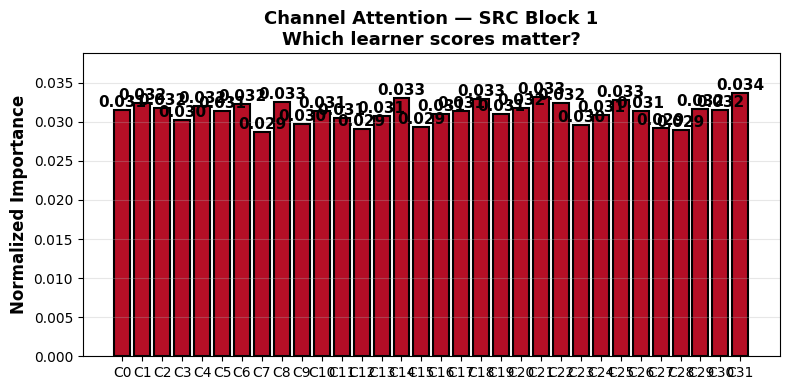

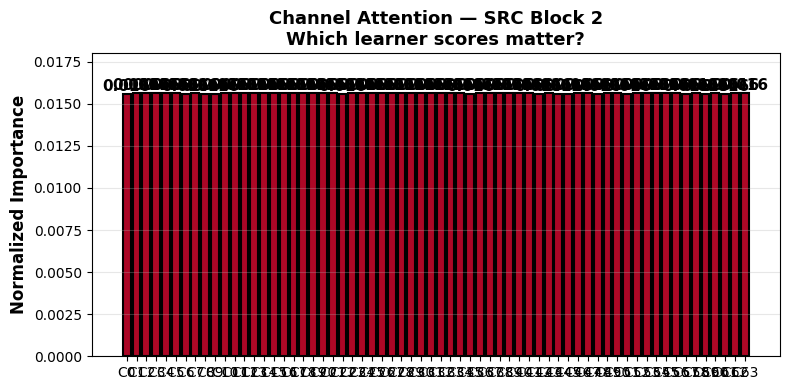

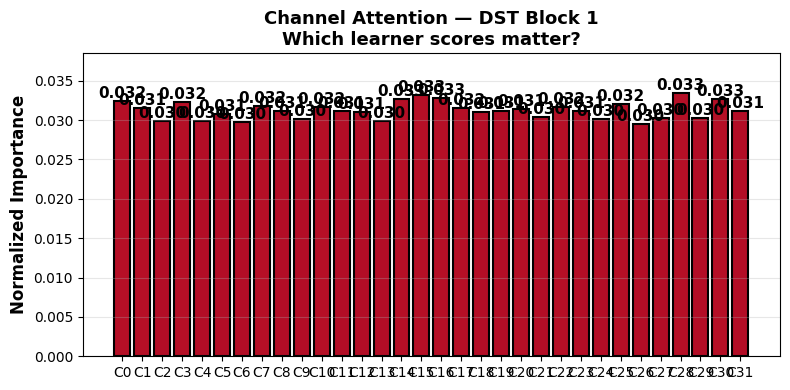

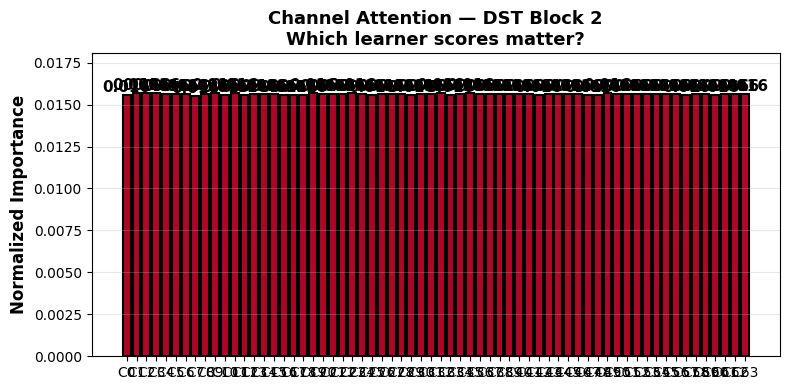

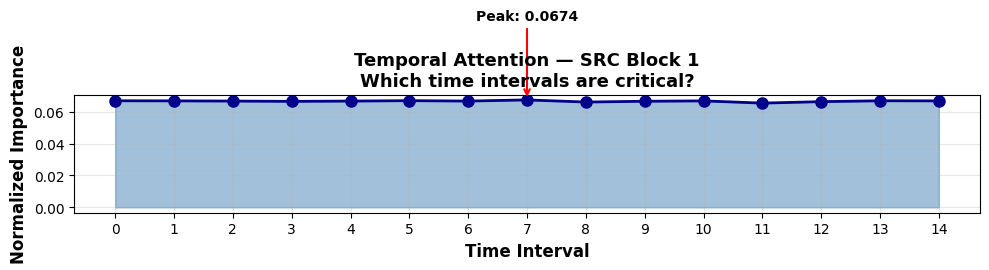

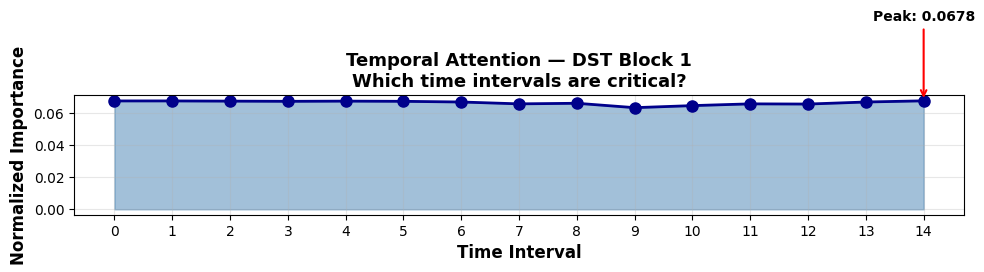

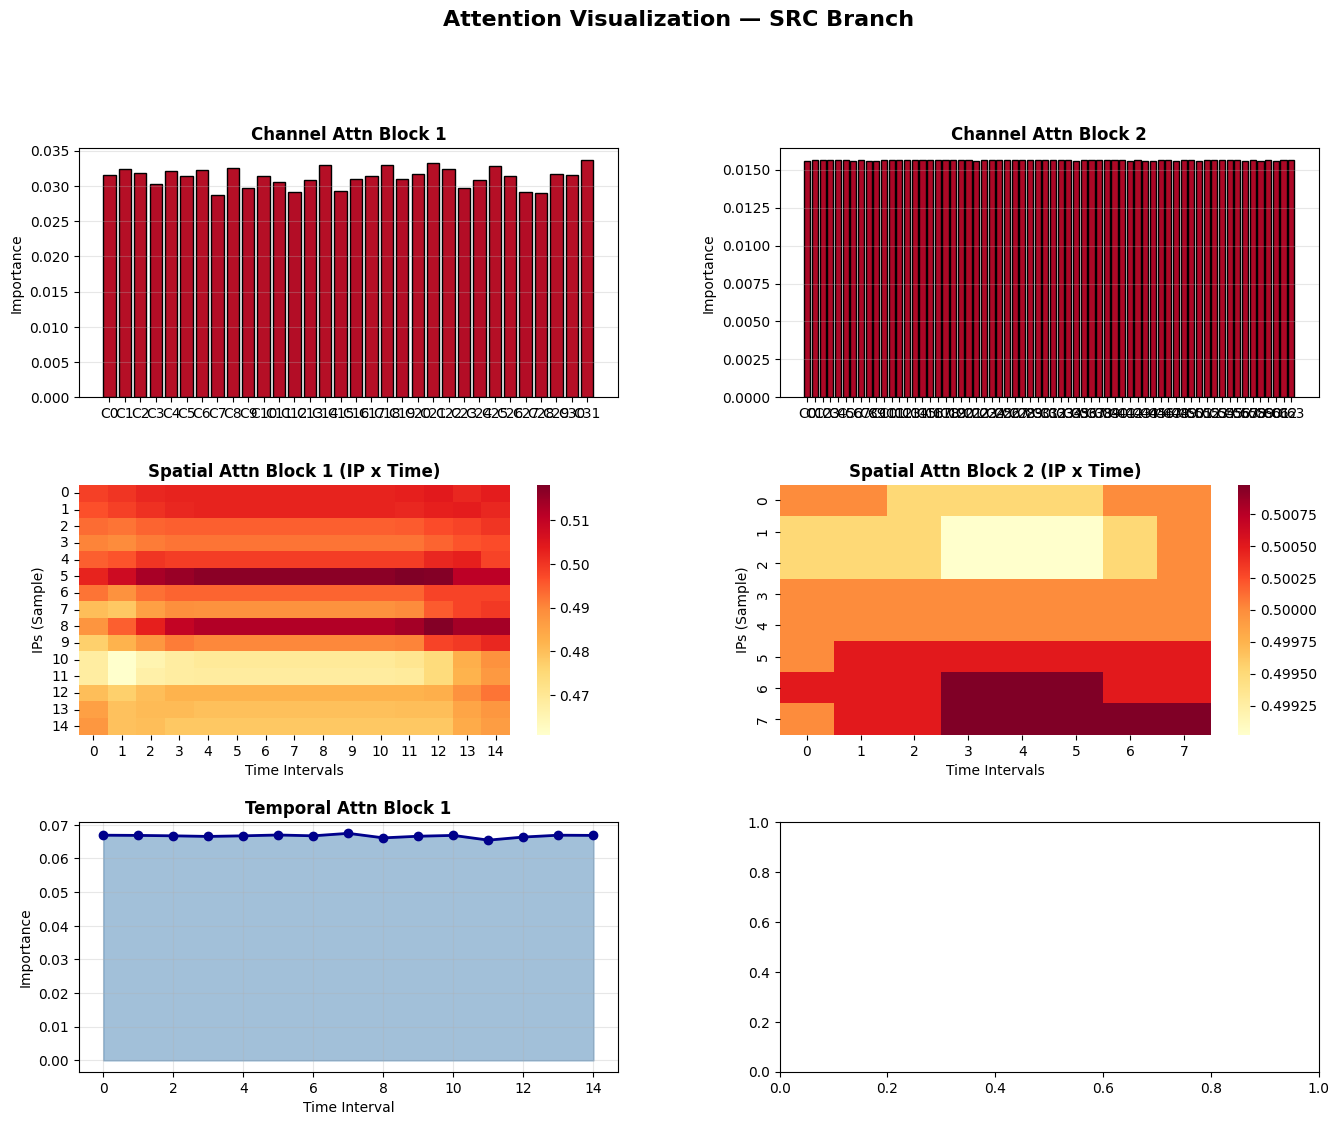

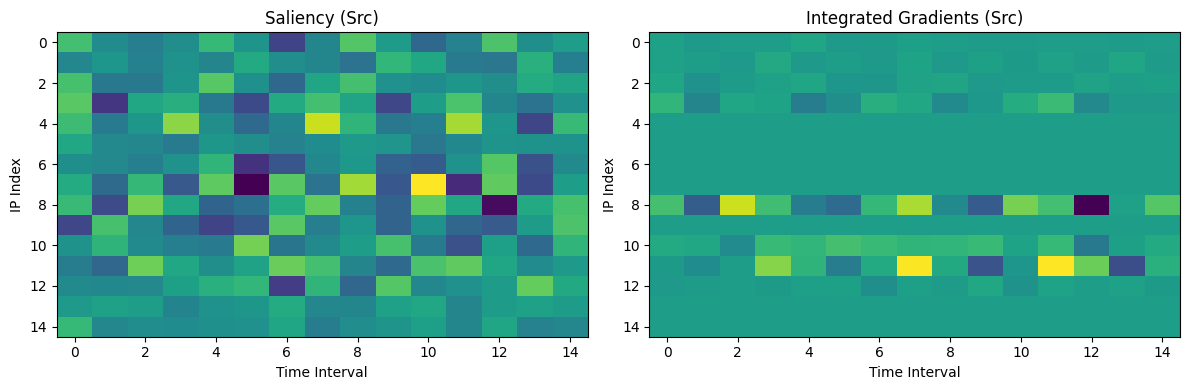

In [6]:
# Visualize attention weights for a single sample
pred, attn_weights = attention_model([sample_src, sample_dst], return_attention=True)

print("Attention weights captured for visualization.")

# Channel attention
for perspective in ['src', 'dst']:
    for block in [1, 2]:
        key = f'{perspective}_channel_attn{block}'
        if key in attn_weights:
            visualizer.visualize_channel_attention(attn_weights[key], perspective=perspective, block=block)
            plt.show()

# Temporal attention
for perspective in ['src', 'dst']:
    for block in [1, 2]:
        key = f'{perspective}_temporal_attn{block}'
        if key in attn_weights:
            visualizer.visualize_temporal_attention(attn_weights[key], perspective=perspective, block=block)
            plt.show()

# Spatial attention heatmap (source branch)
visualizer.visualize_all_attentions(attn_weights, perspective='src')
plt.show()

# Saliency vs Integrated Gradients heatmaps (single sample, src branch)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(sal_src[0].mean(axis=-1), aspect='auto', interpolation='nearest')
axes[0].set_title('Saliency (Src)')
axes[0].set_xlabel('Time Interval')
axes[0].set_ylabel('IP Index')

axes[1].imshow(ig_src[0].mean(axis=-1), aspect='auto', interpolation='nearest')
axes[1].set_title('Integrated Gradients (Src)')
axes[1].set_xlabel('Time Interval')
axes[1].set_ylabel('IP Index')

plt.tight_layout()
plt.show()